# Load Skeletons (from cache)

Reloads a `BrainDataset` previously saved by `load_skeletons.ipynb` via `dataset.save(...)`. Skips the expensive SWC read + graph-building pass.

### Imports

In [1]:
import numpy as np
import os

from agentic_neuron_proofreader.utils import img_util, util
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "zihan_gcs_token.json"
os.environ["AWS_EC2_METADATA_DISABLED"] = "true"

## Section 1: Load From Cache

In [2]:
brain_id = "794495"
segmentation_id = "raw.unet_449_splits_and_merges_900000"

cache_path = f"dataset_cache_{brain_id}.pkl"
dataset = BrainDataset.load_from_cache(cache_path)

# Re-open the (lazy) UNet segmentation reader — also not pickled.
segmentation_path = f"gs://allen-nd-goog/from_google/{brain_id}/whole_brain/{segmentation_id}/"
segmentation = img_util.TensorStoreImage(segmentation_path)

print(dataset.fragments_graph.summary(prefix="Fragments"))
print(dataset.gt_graph.summary(prefix="GroundTruth"))

I0523 20:49:20.918747 115011246 google_auth_provider.cc:149] Using credentials at zihan_gcs_token.json
I0523 20:49:20.919211 115011246 google_auth_provider.cc:165] Using ServiceAccount AuthProvider


Fragments Graph
# Connected Components: 10,172
# Nodes: 4,281,310
# Edges: 4,271,138
Memory Consumption: 6.07 GBs
GroundTruth Graph
# Connected Components: 19
# Nodes: 1,363,808
# Edges: 1,363,789
Memory Consumption: 6.13 GBs


1363808


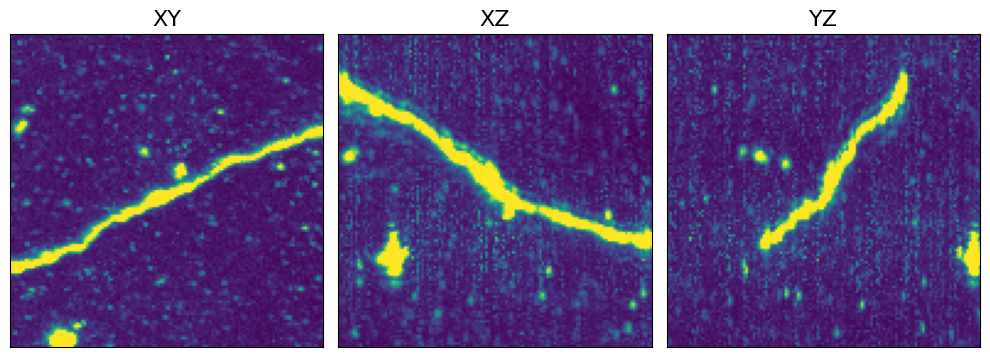

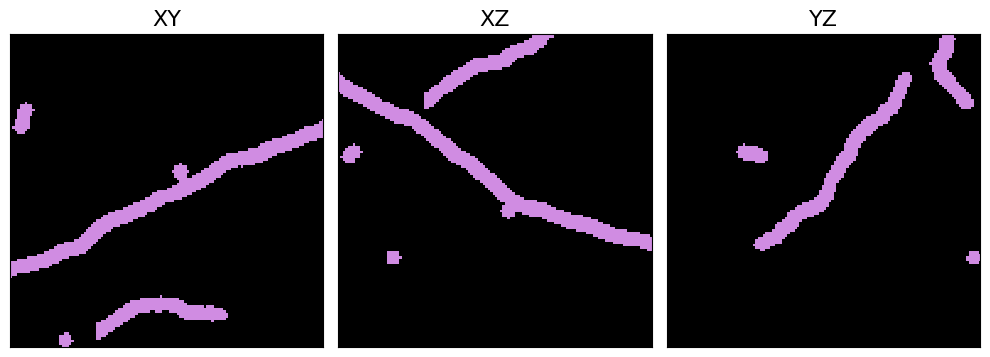

In [5]:
# Parameters
# patch_shape: size of the (z, y, x) voxel cube to read around the sampled center.
patch_shape = (128, 128, 128)

# use_groundtruth: chooses WHICH skeleton graph to randomly sample a center voxel
#   from. It does NOT control what gets plotted -- both figures below always show
#   the raw image and the UNet segmentation.
#     True  -> center on a human-traced (GT) node => patch is guaranteed to
#              contain a real neurite. Good for asking "did the UNet correctly
#              segment a real neuron here?"
#     False -> center on a UNet fragment node => patch is wherever the model
#              flagged a >= min_cable_length fragment. Good for asking "is this
#              UNet fragment real or a false positive?"
use_groundtruth = True

print(len(dataset.gt_graph.nodes))

# Sample a single random node from the chosen graph and convert it to a voxel
# coordinate. This voxel is just the *center* of the patch; the GT/fragment
# graph only contributes a location, not pixels.
if use_groundtruth:
    node = util.sample_once(dataset.gt_graph.nodes)
    voxel = dataset.gt_graph.node_voxel(node)
else:
    node = util.sample_once(dataset.fragments_graph.nodes)
    voxel = dataset.fragments_graph.node_voxel(node)

# Read aligned patches at the same center.
#   img_patch          -- raw ExaSPIM fluorescence (dataset.img)
#   segmentation_patch -- UNet predicted label volume (segmentation_path,
#                         i.e. raw.unet_449_splits_and_merges_900000)
img_patch = dataset.img.read(voxel, patch_shape)
segmentation_patch = segmentation.read(voxel, patch_shape)

# Plot MIPs. Note: plot_segmentation_mips ALWAYS shows the UNet mask -- there
# is no dense ground-truth volume in this dataset (GT is skeleton-only and
# lives in dataset.gt_graph). To see GT, look at the skeleton-MIP cell below.
img_util.plot_mips(img_patch)
img_util.plot_segmentation_mips((segmentation_patch > 0).astype(int))

### Combined Visualization: Image + UNet Segmentation + Skeletons

GT nodes in patch:        36
Fragment nodes in patch:  29


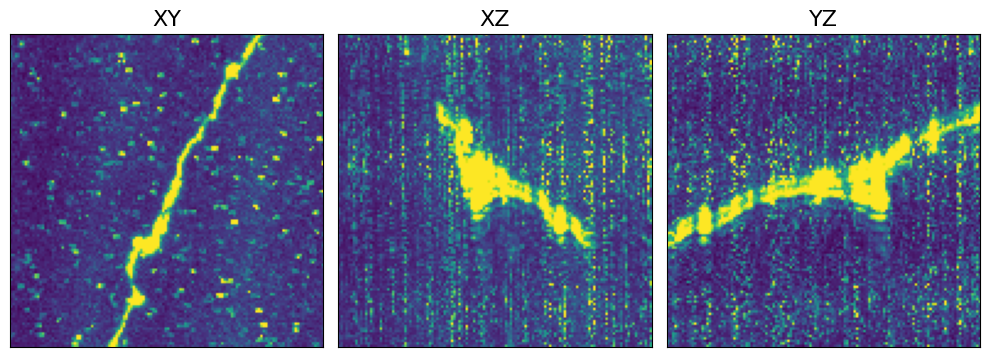

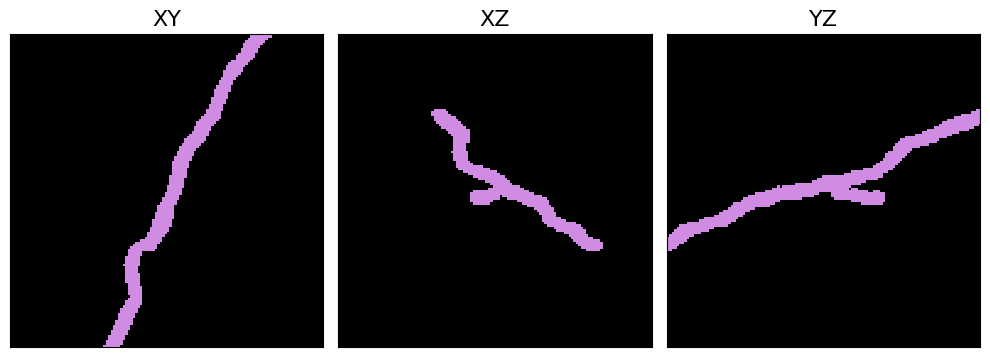

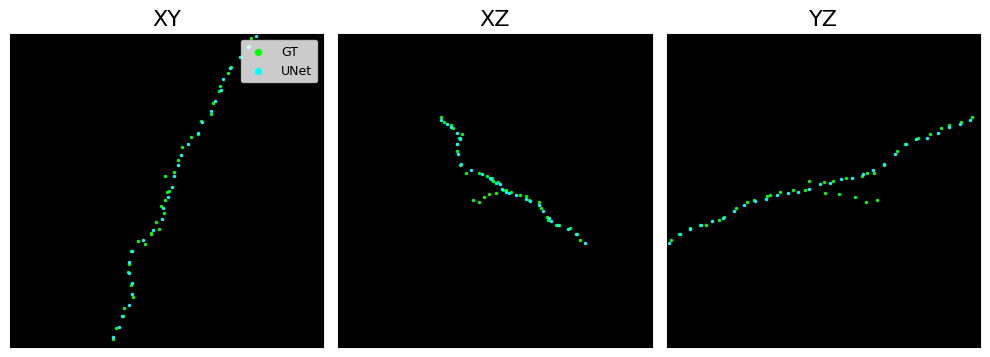

In [6]:
# Parameters
patch_shape = (128, 128, 128)
use_groundtruth = True

# Sample a center voxel from either GT or UNet fragments graph
src_graph = dataset.gt_graph if use_groundtruth else dataset.fragments_graph
node = util.sample_once(src_graph.nodes)
center_voxel = src_graph.node_voxel(node)

# Read aligned image + segmentation patches at the same location
img_patch = dataset.img.read(center_voxel, patch_shape)
seg_patch = segmentation.read(center_voxel, patch_shape)
seg_mask = (seg_patch > 0).astype(int)

# Patch origin in global voxel space (for converting global -> local coords)
offset = tuple(c - s // 2 for c, s in zip(center_voxel, patch_shape))

# Find skeleton nodes inside the patch
gt_local = dataset.gt_graph.nodes_in_patch(offset, patch_shape)
frag_local = dataset.fragments_graph.nodes_in_patch(offset, patch_shape)
print(f"GT nodes in patch:        {len(gt_local)}")
print(f"Fragment nodes in patch:  {len(frag_local)}")

# Plot 3 separate MIP figures for the same volume
img_util.plot_mips(img_patch)
img_util.plot_segmentation_mips(seg_mask)
img_util.plot_skeleton_mips(
    {"GT": (gt_local, "lime"), "UNet": (frag_local, "cyan")},
    patch_shape,
)